# Parameter Sweep: Symmetry-Breaking ("New Inflation") $\mu$

$V=V_0[1-(\phi/\mu)^2]^2$ -- a standard double-well/symmetry-breaking potential, structurally different from hilltop (squared, different extremum structure). **Classification: SCALE-type** ($\mu$ purely rescales $\phi$; the shape function $s(x)=(1-x^2)^2$ is fixed).

For every $\mu$, $\phi_i$ is found by root-finding on the exact background ODE to hit $N_{\rm end}=65$, and $V_0$ would be tuned to the pivot benchmark (omitted here since only $n_s,r$ are needed, which are $V_0$-independent).

In [1]:
import numpy as np
from scipy import integrate
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
import matplotlib.pyplot as plt

def background_eqn(N, fields, potential):
    phi, dphidN = fields
    v, dvdphi = potential(phi)
    d2phidN2 = -(3. - 0.5*(dphidN*dphidN))*dphidN \
               - (6. - (dphidN*dphidN))*dvdphi/(2.*v)
    return [dphidN, d2phidN2]

def Hubble(phi_N, V):
    return np.sqrt(V/(3 - 0.5*(phi_N*phi_N)))

def epsilon1(phi_N):
    return 0.5*phi_N*phi_N

def stop_integration(N, y):
    return 0.5*(y[1]**2) - 1
stop_integration.terminal = True
stop_integration.direction = 0

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx, array[idx]

def z_of(a, phi_N):
    return a*phi_N

def solve_background(potential, ph_initial, t_end=120.0, fine_step=2e-3):
    efolds_fine = np.arange(0, t_end, fine_step)
    sol = solve_ivp(lambda N, y: background_eqn(N, y, potential),
                     [0, t_end], ph_initial, method='RK45',
                     dense_output=True, events=(stop_integration,), max_step=np.inf)
    Nend = sol.t_events[0][0] if len(sol.t_events[0]) > 0 else sol.t[-1]
    mask = efolds_fine < Nend
    efolds = efolds_fine[mask]
    y = sol.sol(efolds)
    phi, dphi = y[0], y[1]
    pot, dpotdphi = potential(phi)
    Hub = Hubble(dphi, pot)
    return dict(efolds=efolds, phi=phi, dphi=dphi, pot=pot,
                dpotdphi=dpotdphi, Hub=Hub, Nend=Nend)

def pert_eqn(y, N, k, ai, potential):
    phi, dphidN, Rk_re, Rk_re_N, Rk_im, Rk_im_N, hk_re, hk_re_N, hk_im, hk_im_N = y
    v, dvdphi = potential(phi)
    d2phidN2 = -(3. - 0.5*(dphidN*dphidN))*dphidN - (6. - (dphidN*dphidN))*dvdphi/(2.*v)
    a = ai*np.exp(N)
    H = np.sqrt(v/(3 - 0.5*(dphidN*dphidN)))
    zN = a*(dphidN + d2phidN2)
    zval = z_of(a, dphidN)
    Rk_re_NN = -(1 - (dphidN**2)*0.5 + 2.0*(zN/zval))*Rk_re_N - ((k/(a*H))**2)*Rk_re
    Rk_im_NN = -(1 - (dphidN**2)*0.5 + 2.0*(zN/zval))*Rk_im_N - ((k/(a*H))**2)*Rk_im
    hk_re_NN = -(3 - (dphidN**2)*0.5)*hk_re_N - ((k/(a*H))**2)*hk_re
    hk_im_NN = -(3 - (dphidN**2)*0.5)*hk_im_N - ((k/(a*H))**2)*hk_im
    return [dphidN, d2phidN2, Rk_re_N, Rk_re_NN, Rk_im_N, Rk_im_NN,
            hk_re_N, hk_re_NN, hk_im_N, hk_im_NN]

def boundary(k, t, aH, Nic_cond, Nshs_cond):
    ic_diff = k - Nic_cond*aH
    shs_diff = k - Nshs_cond*aH
    idx_ic, _ = find_nearest(ic_diff, 0)
    idx_shs, _ = find_nearest(shs_diff, 0)
    return idx_ic, t[idx_ic], t[idx_shs]

def initial_condition(idx_ic, k, efolds, phi, dphi, ai, Hub, potential):
    phi_ic = phi[idx_ic]; phiN_ic = dphi[idx_ic]
    a_ic = ai*np.exp(efolds[idx_ic]); z_ic = z_of(a_ic, phiN_ic); H_ic = Hub[idx_ic]
    _, phiNN_ic = background_eqn(efolds[idx_ic], [phi_ic, phiN_ic], potential)
    Rk_re_ic = (1/(np.sqrt(2*k)))/z_ic
    Rk_im_ic = 0
    Rk_re_N_ic = -Rk_re_ic*((phiNN_ic/phiN_ic) + 1)
    Rk_im_N_ic = -np.sqrt(k/2)/(a_ic*H_ic*z_ic)
    hk_re_ic = (1/(np.sqrt(2*k)))/a_ic
    hk_im_ic = 0
    hk_re_N_ic = -hk_re_ic
    hk_im_N_ic = -np.sqrt(k/2)/(a_ic*H_ic*a_ic)
    return [phi_ic, phiN_ic, Rk_re_ic, Rk_re_N_ic, Rk_im_ic, Rk_im_N_ic,
            hk_re_ic, hk_re_N_ic, hk_im_ic, hk_im_N_ic]

def Psk(kk, Rk):
    Rk_re, Rk_im = Rk
    return kk**3/(2e0*np.pi**2)*((Rk_re*Rk_re)+(Rk_im*Rk_im))

def Pth(kk, hk):
    hk_re, hk_im = hk
    return 8.0*kk**3/(2e0*np.pi**2)*((hk_re*hk_re)+(hk_im*hk_im))

class InflationRun:
    def __init__(self, potential, bg, kpivot=0.05, Nic_cond=100, Nshs_cond=1e-5):
        self.potential = potential
        self.efolds = bg['efolds']; self.phi = bg['phi']; self.dphi = bg['dphi']
        self.Hub = bg['Hub']; self.Nend = bg['Nend']
        self.Nic_cond = Nic_cond; self.Nshs_cond = Nshs_cond
        idx50, Ne50 = find_nearest(self.efolds, self.Nend - 50)
        self.idx50, self.Ne50 = idx50, Ne50
        self.ai = kpivot/(np.exp(Ne50)*self.Hub[idx50])
        self.kpivot = kpivot

    def compute_pps(self, kk, atol=1e-11):
        idx_ic, Nic, Nshs = boundary(kk, self.efolds, self.ai*np.exp(self.efolds)*self.Hub,
                                      self.Nic_cond, self.Nshs_cond)
        efolds_pert = np.arange(Nic, Nshs, 0.01)
        pert_ic = initial_condition(idx_ic, kk, self.efolds, self.phi, self.dphi,
                                     self.ai, self.Hub, self.potential)
        sol_pert = integrate.odeint(pert_eqn, pert_ic, efolds_pert,
                                     args=(kk, self.ai, self.potential), atol=atol)
        Rkshs = [sol_pert[-1,2], sol_pert[-1,4]]
        hkshs = [sol_pert[-1,6], sol_pert[-1,8]]
        return Psk(kk, Rkshs), Pth(kk, hkshs), efolds_pert, sol_pert, Nic, Nshs


In [2]:
def symbreak_potential(phi, mu, V0=1e-11):
    x = phi/mu
    v = V0*(1-x**2)**2
    dv = V0*2*(1-x**2)*(-2*x/mu)
    return v, dv

def eps_eta_symbreak(phi, mu):
    x = phi/mu
    s = (1-x**2)**2
    sp = -4*x*(1-x**2)/mu
    spp = (12*x**2-4)/mu**2
    return 0.5*(sp/s)**2, spp/s

# verify analytic formulas against finite differences before trusting them
def verify(phi_test, mu):
    h = 1e-6
    pot = lambda phi: symbreak_potential(phi, mu)
    V0,dV0 = pot(phi_test)
    Vp,_ = pot(phi_test+h); Vm,_ = pot(phi_test-h)
    d2V_fd = (Vp - 2*V0 + Vm)/h**2
    eps_a, eta_a = eps_eta_symbreak(phi_test, mu)
    print(f'phi={phi_test}, mu={mu}: eps analytic={eps_a:.6f} fd={0.5*(dV0/V0)**2:.6f} | '
          f'eta analytic={eta_a:.6f} fd={d2V_fd/V0:.6f}')

verify(1.5, 6.0)
verify(4.0, 6.0)

phi=1.5, mu=6.0: eps analytic=0.015802 fd=0.015802 | eta analytic=-0.102716 fd=-0.102570
phi=4.0, mu=6.0: eps analytic=0.320000 fd=0.320000 | eta analytic=0.120000 fd=0.120132


## Calibration + sweep

In [3]:
TARGET_NEND = 65.0

def calibrate_ns_r(pot, eps_eta_fn, phi_i_guess_lo, phi_i_guess_hi):
    def Nend_of_phi(phi_i):
        ph=[phi_i, None]; V,dV = pot(phi_i); ph[1]=-dV/V
        return solve_background(pot, ph, t_end=150, fine_step=2e-3)['Nend']
    phi_i = brentq(lambda p: Nend_of_phi(p)-TARGET_NEND, phi_i_guess_lo, phi_i_guess_hi, xtol=1e-7)
    ph=[phi_i, None]; V,dV = pot(phi_i); ph[1]=-dV/V
    bg = solve_background(pot, ph, t_end=150, fine_step=5e-4)
    run = InflationRun(pot, bg, kpivot=0.05, Nic_cond=100)
    phi_star = bg['phi'][run.idx50]
    eps_v, eta_v = eps_eta_fn(phi_star)
    ns = 1 - 6*eps_v + 2*eta_v
    r = 16*eps_v
    return phi_i, ns, r

mu_values = np.array([5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 9.0, 10.0])
results = []
for mu in mu_values:
    pot = lambda phi: symbreak_potential(phi, mu)
    eps_eta = lambda phi: eps_eta_symbreak(phi, mu)
    phi_i, ns, r = calibrate_ns_r(pot, eps_eta, 1e-4, mu*0.9999)
    results.append(dict(mu=mu, phi_i=phi_i, ns=ns, r=r))
    print(f'mu={mu}: phi_i={phi_i:.5f}  ns={ns:.4f}  r={r:.6e}')

/tmp/ipykernel_539/2136910039.py:10: RuntimeWarning: overflow encountered in scalar multiply
  d2phidN2 = -(3. - 0.5*(dphidN*dphidN))*dphidN \
/tmp/ipykernel_539/2136910039.py:11: RuntimeWarning: overflow encountered in scalar multiply
  - (6. - (dphidN*dphidN))*dvdphi/(2.*v)
/tmp/ipykernel_539/2190370046.py:3: RuntimeWarning: overflow encountered in scalar power
  v = V0*(1-x**2)**2
/tmp/ipykernel_539/2190370046.py:4: RuntimeWarning: overflow encountered in scalar multiply
  dv = V0*2*(1-x**2)*(-2*x/mu)
/tmp/ipykernel_539/2136910039.py:11: RuntimeWarning: invalid value encountered in scalar divide
  - (6. - (dphidN*dphidN))*dvdphi/(2.*v)
/tmp/ipykernel_539/2136910039.py:15: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(V/(3 - 0.5*(phi_N*phi_N)))


mu=5.0: phi_i=0.00016  ns=0.6800  r=4.824126e-07
mu=5.5: phi_i=0.00089  ns=0.7355  r=5.049022e-06


/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)


mu=6.0: phi_i=0.00348  ns=0.7778  r=3.002608e-05
mu=6.5: phi_i=0.01027  ns=0.8106  r=1.192204e-04


mu=7.0: phi_i=0.02464  ns=0.8366  r=3.522311e-04
mu=7.5: phi_i=0.05059  ns=0.8575  r=8.346430e-04


mu=8.0: phi_i=0.09218  ns=0.8745  r=1.672745e-03
mu=9.0: phi_i=0.23566  ns=0.8998  r=4.695292e-03


mu=10.0: phi_i=0.47310  ns=0.9170  r=9.554230e-03


## Plots + classification check (log-linear vs plain-linear $R^2$)

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_539/2912479368.py:7: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title('$n_s$ vs $\mu$')
/tmp/ipykernel_539/2912479368.py:9: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_title('$r$ vs $\mu$')


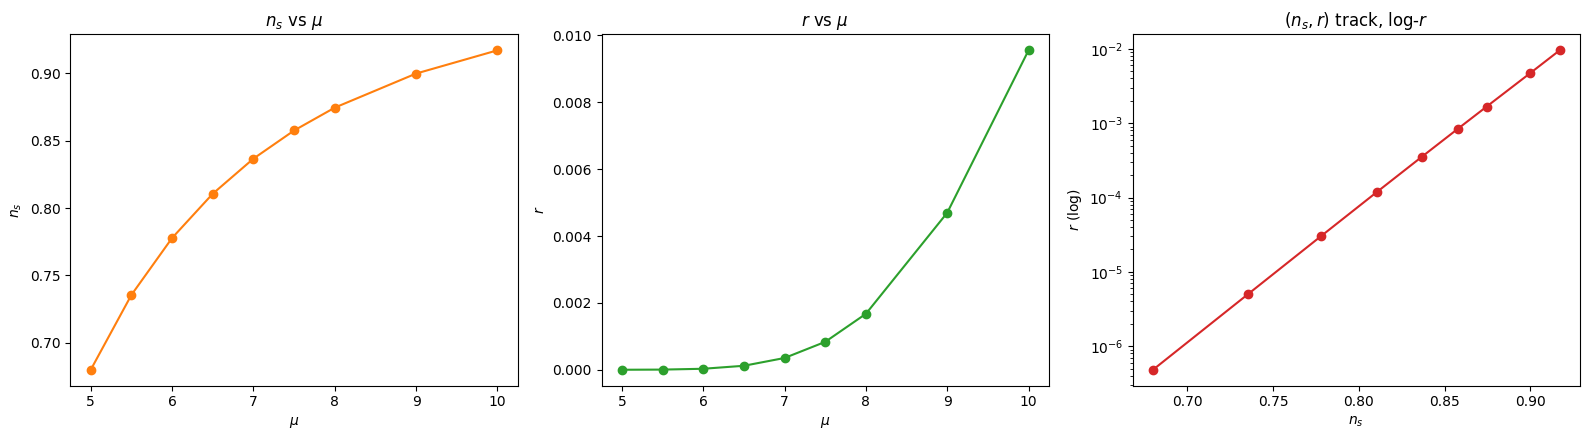

R^2 log-linear (exponential fit):  0.9999
R^2 plain-linear fit:              0.4830
Monotonic in r: True


In [4]:
mus = [x['mu'] for x in results]
ns_vals = np.array([x['ns'] for x in results])
r_vals = np.array([x['r'] for x in results])

fig, axes = plt.subplots(1, 3, figsize=(16,4.5))
axes[0].plot(mus, ns_vals, 'o-', color='C1'); axes[0].set_xlabel(r'$\mu$'); axes[0].set_ylabel('$n_s$')
axes[0].set_title('$n_s$ vs $\mu$')
axes[1].plot(mus, r_vals, 'o-', color='C2'); axes[1].set_xlabel(r'$\mu$'); axes[1].set_ylabel('$r$')
axes[1].set_title('$r$ vs $\mu$')
axes[2].plot(ns_vals, r_vals, 'o-', color='C3')
axes[2].set_yscale('log'); axes[2].set_xlabel('$n_s$'); axes[2].set_ylabel('$r$ (log)')
axes[2].set_title('$(n_s,r)$ track, log-$r$')
plt.tight_layout(); plt.show()

def r2(x, y):
    coef = np.polyfit(x, y, 1); pred = np.polyval(coef, x)
    return 1 - np.sum((y-pred)**2)/np.sum((y-np.mean(y))**2)

print(f'R^2 log-linear (exponential fit):  {r2(ns_vals, np.log(r_vals)):.4f}')
print(f'R^2 plain-linear fit:              {r2(ns_vals, r_vals):.4f}')
print('Monotonic in r:', np.all(np.diff(r_vals)>0) or np.all(np.diff(r_vals)<0))